### 역행렬(inverse mAtrix)

정방 행렬(square matrix) A에 대해 $AA^{-1} = I$(identity matrix, 단위행렬)를 만족하는 $A^{-1}$을 역행렬(inverse matrix)이라 한다. 

행렬식(determinant)이 $ad - bc != 0$일 때 역행렬이 존재하며 이를 가역행렬(invertible matrix)라고 한다. [Q]

$A = \left(\begin{matrix}
a & b\\
c & d \\
\end{matrix}\right)$

In [ ]:
def getInverseMatrix(matrix):
    """행렬의 가역성 판별 및 역행렬 계산 메서드"""
    return

### Gauss-Jordan 소거법 

- 역행렬을 구하는 가장 표준적인 알고리즘으로, $[A \mid I]$ 형태의 첨가행렬을 만들고, A를 I로 만드는 행 연산을 I에도 적용 $[I \mid A^{-1}]$을 얻을 수 있다.
- 출처 : https://aaaaaaaaaaayowooji.tistory.com/50#google_vignette

In [ ]:
def GaussJordanInverse(matrix):
    """가우스-조르단 소거법을 이용한 역행렬 계산 메서드"""
    return

### 행렬분해(Lower-Upper Factorization)

* $\mathbf{L}$, 하삼각행렬과 $\mathbf{R}$ 상삼각행렬의 곱으로 나누는 기법
* 이는 연립방정식(linear system)을 효율적으로 풀거나 행렬의 구조를 파악하는데 도움이 된다. 가우스 소거법을 통해 $A$를 $U$(echelon form)로 변환하는 과정에서 사용되는 행 연산의 역연산을 L(unit lower triangular matrix)에 기록한다. 
* 즉, 이때 단계별로(열 별로) 별도의 행연산, 즉 별도의 단위행렬로부터 행연산을 수행하여 기록한다.
* 출처 : 

In [ ]:
import numpy as np
from scipy.linalg import lu
# parameters : array_like, permute_l : bool, optional(PL, row exchange YN), check_finite : bool, optional, p_indices : array_like
# returns : array P, array L, array U

In [12]:
def getLUFactorization(matrix):
    """행렬의 LU 분해 메서드 [as-is]"""
    A = matrix.copy()
    # LU 분해를 위한 계수행렬 복사
    n = len(A)
    # 행렬 A의 크기 계산
    L = np.eye(n)
    # unit lower triangular matrix를 초기화
    # A를 행 연산을 통해 윗 삼각 행렬(행 사다리꼴, EF)로 변환
    U = A.copy()
    # upper triangular matrix 
    # 대각성분이 1이고, U를 만드는 과정에서 사용된 피벗(pivot) 배수들로 구성된 아랫 삼각 행렬

    for i in range(n):
        for j in range(i+1, n):
            factor = U[j][i] / U[i][i] (j = i+1)
            # 1열부터 n열까지의 요소들을 0으로 만들기 위한 배수 계산
            # 1열에 대한 기초 행연산 {i=1, j=2} -> factor = U[2][1] / U[1][1]

            U[j] = U[j] - factor * U[i]
            # U의 j번째 행에서 i번째 행의 factor배를 빼서 U의 j번째 행을 업데이트
            L[j][i] = factor
            # L의 j번째 행에서 i번째 열에 factor를 저장하여 L을 업데이트
            # [as-is]
    return L, U

### Doolittle 알고리즘

* **핵심**: L의 대각 성분을 1로 고정하고 U와 L을 순서대로 계산

> $A = \begin{pmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{pmatrix}, \quad L = \begin{pmatrix} 1 & 0 & 0 \\ l_{21} & 1 & 0 \\ l_{31} & l_{32} & 1 \end{pmatrix}, \quad U = \begin{pmatrix} u_{11} & u_{12} & u_{13} \\ 0 & u_{22} & u_{23} \\ 0 & 0 & u_{33} \end{pmatrix}$

* **Doolittle 알고리즘 공식 유도**

> $A = LU$를 직접 전개하면:

> $\begin{pmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{pmatrix} = \begin{pmatrix} 1 & 0 & 0 \\ l_{21} & 1 & 0 \\ l_{31} & l_{32} & 1 \end{pmatrix} \begin{pmatrix} u_{11} & u_{12} & u_{13} \\ 0 & u_{22} & u_{23} \\ 0 & 0 & u_{33} \end{pmatrix}$

* **행렬 곱셈을 직접 계산:**

* **1행** (L의 1행 = $[1, 0, 0]$이므로 그대로):
> $u_{11} = a_{11}, \quad u_{12} = a_{12}, \quad u_{13} = a_{13}$

* **2행**:
> $a_{21} = l_{21} \cdot u_{11} \quad \Rightarrow \quad l_{21} = \frac{a_{21}}{u_{11}}$
> $a_{22} = l_{21} \cdot u_{12} + 1 \cdot u_{22} \quad \Rightarrow \quad u_{22} = a_{22} - l_{21} \cdot u_{12}$
> $a_{23} = l_{21} \cdot u_{13} + 1 \cdot u_{23} \quad \Rightarrow \quad u_{23} = a_{23} - l_{21} \cdot u_{13}$

* **3행**:
> $a_{31} = l_{31} \cdot u_{11} \quad \Rightarrow \quad l_{31} = \frac{a_{31}}{u_{11}}$
> $a_{32} = l_{31} \cdot u_{12} + l_{32} \cdot u_{22} \quad \Rightarrow \quad l_{32} = \frac{a_{32} - l_{31} \cdot u_{12}}{u_{22}}$
> $a_{33} = l_{31} \cdot u_{13} + l_{32} \cdot u_{23} + u_{33} \quad \Rightarrow \quad u_{33} = a_{33} - l_{31} \cdot u_{13} - l_{32} \cdot u_{23}$

---

**위 패턴을 일반화하면:**

> $\boxed{U[i][j] = A[i][j] - \sum_{k=0}^{i-1} L[i][k] \times U[k][j]} \quad (j \geq i)$

> $\boxed{L[i][j] = \frac{1}{U[j][j]} \left( A[i][j] - \sum_{k=0}^{j-1} L[i][k] \cdot U[k][j] \right)} \quad (i > j)$

> **계산 순서**: 열 단위로 U의 행 → L의 열 순서로 채워나감

* **U 계산 공식** (위에서 아래, 왼쪽에서 오른쪽):
> $U[i][j] = A[i][j] - \sum_{k=0}^{i-1} L[i][k] \times U[k][j] \quad (j \geq i)$

* **L 계산 공식** (U의 대각성분으로 나눔):
> $L[i][j] = \frac{1}{U[j][j]} \left( A[i][j] - \sum_{k=0}^{j-1} L[i][k] \cdot U[k][j] \right) \quad (i > j)$

* **주의**: $U[j][j] = 0$이면 LU 분해 불가능 → PLU 분해 필요

In [ ]:
def getLUDecomposition(matrix):
    """행렬의 LU 분해 메서드
    Logics:
    - doolittle algorithm을 이용하여 행렬 A를 L과 U로 분해
    - L행렬의 대각성분을 1로 고정하여 U행렬의 대각성분이 A의 대각성분과 일치하도록 분해"""
    return

In [13]:
# LU 분해를 이용한 역행렬 계산 알고리즘

a = np.array([[-1,2,-4], [2,-5,10], [3,1,6]], dtype = float)
print("계수행렬 A:\n", a,"\n") 
# 계수행렬 A

# 1열에 대해 기초 행연산
record_1_0 = a[1][0] / a[0][0] 
# record 추출
print("1열에 대한 기초 행연산에서 사용된 배수:", record_1_0) 
# 1열에 대한 기초 행연산에서 사용된 배수
a[1] += (-1) * a[1][0] / a[0][0] * a[0]
print("1열에 대한 기초 행연산 후의 행렬 A:\n", a,"\n") 
# 1열에 대한 기초 행연산 후의 행렬 A

record_2_0 = a[2][0] / a[0][0] 
# record 추출
print("1열에 대한 기초 행연산에서 사용된 배수:", record_2_0) 
# 1열에 대한 기초 행연산에서 사용된 배수
a[2] += (-1) * a[2][0] / a[0][0] * a[0]
print("1열에 대한 기초 행연산 후의 행렬 A:\n", a,"\n") 
# 1열에 대한 기초 행연산 후의 행렬 A

# 2열에 대해 기초 행연산
record_2_1 = a[2][1] / a[1][1]
# record 추출
print("2열에 대한 기초 행연산에서 사용된 배수:", record_2_1) 
# 2열에 대한 기초 행연산에서 사용된 배수
a[2] += (-1) * a[2][1] / a[1][1] * a[1]
print("2열에 대한 기초 행연산 후의 행렬 A:\n", a,"\n") 
# 2열에 대한 기초 행연산 후의 행렬 A
print("상삼각행렬 U:\n", a,"\n") 
# 상삼각행렬 U

계수행렬 A:
 [[-1.  2. -4.]
 [ 2. -5. 10.]
 [ 3.  1.  6.]] 

1열에 대한 기초 행연산에서 사용된 배수: -2.0
1열에 대한 기초 행연산 후의 행렬 A:
 [[-1.  2. -4.]
 [ 0. -1.  2.]
 [ 3.  1.  6.]] 

1열에 대한 기초 행연산에서 사용된 배수: -3.0
1열에 대한 기초 행연산 후의 행렬 A:
 [[-1.  2. -4.]
 [ 0. -1.  2.]
 [ 0.  7. -6.]] 

2열에 대한 기초 행연산에서 사용된 배수: -7.0
2열에 대한 기초 행연산 후의 행렬 A:
 [[-1.  2. -4.]
 [ 0. -1.  2.]
 [ 0.  0.  8.]] 

상삼각행렬 U:
 [[-1.  2. -4.]
 [ 0. -1.  2.]
 [ 0.  0.  8.]] 



In [18]:
# 하삼각행렬 L 계산 (1)

I = np.identity(3, dtype = float)
# 크기가 3인 단위행렬 I

I[1] += record_1_0 * np.identity(3, dtype = float)[0]
# 1열에 대한 기초 행연산에서 사용된 배수 record_1_0를 이용
# I의 1행에 record_1_0배를 더하기

I[2] += record_2_0 * np.identity(3, dtype = float)[0]
# 1열에 대한 기초 행연산에서 사용된 배수 record_2_0를 이용
# I의 2행에 record_2_0배를 더하기

I[2] += record_2_1 * np.identity(3, dtype = float)[1]
# 2열에 대한 기초 행연산에서 사용된 배수 record_2_1를 이용
# I의 2행에 record_2_1배를 더하기

print("하삼각행렬 L:\n", I,"\n")
# 하삼각행렬 L

하삼각행렬 L:
 [[ 1.  0.  0.]
 [-2.  1.  0.]
 [-3. -7.  1.]] 



In [19]:
# 하삼각행렬 L 계산 (2)

I = np.identity(3, dtype = float)
# 크기가 3인 단위행렬 I

I[1][0] = record_1_0
# record_1_0를 I의 1행 0열에 저장(record가 기록된 위치에 해당하는 위치에 배수를 저장)

I[2][0] = record_2_0
# record_2_0를 I의 2행 0열에 저장(record가 기록된 위치에 해당하는 위치에 배수를 저장)

I[2][1] = record_2_1
# record_2_1를 I의 2행 1열에 저장(record가 기록된 위치에 해당하는 위치에 배수를 저장)   

print("하삼각행렬 L:\n", I,"\n")
# 하삼각행렬 L

하삼각행렬 L:
 [[ 1.  0.  0.]
 [-2.  1.  0.]
 [-3. -7.  1.]] 



In [21]:
det_a = 1
# 상삼각행렬 U의 대각선 원소들의 곱으로 행렬식 계산
# 성질: det(A) = det(L) * det(U), 그리고 det(L) = 1 (단위 하삼각행렬)
# 따라서 det(A) = det(U) = U[0][0] * U[1][1] * U[2][2] (상삼각행렬의 행렬식)

det_a *= a[0][0]  # 첫 번째 대각 성분
det_a *= a[1][1]  # 두 번째 대각 성분
det_a *= a[2][2]  # 세 번째 대각 성분
print(f"행렬식 det(A) = {det_a}")

행렬식 det(A) = 8.0


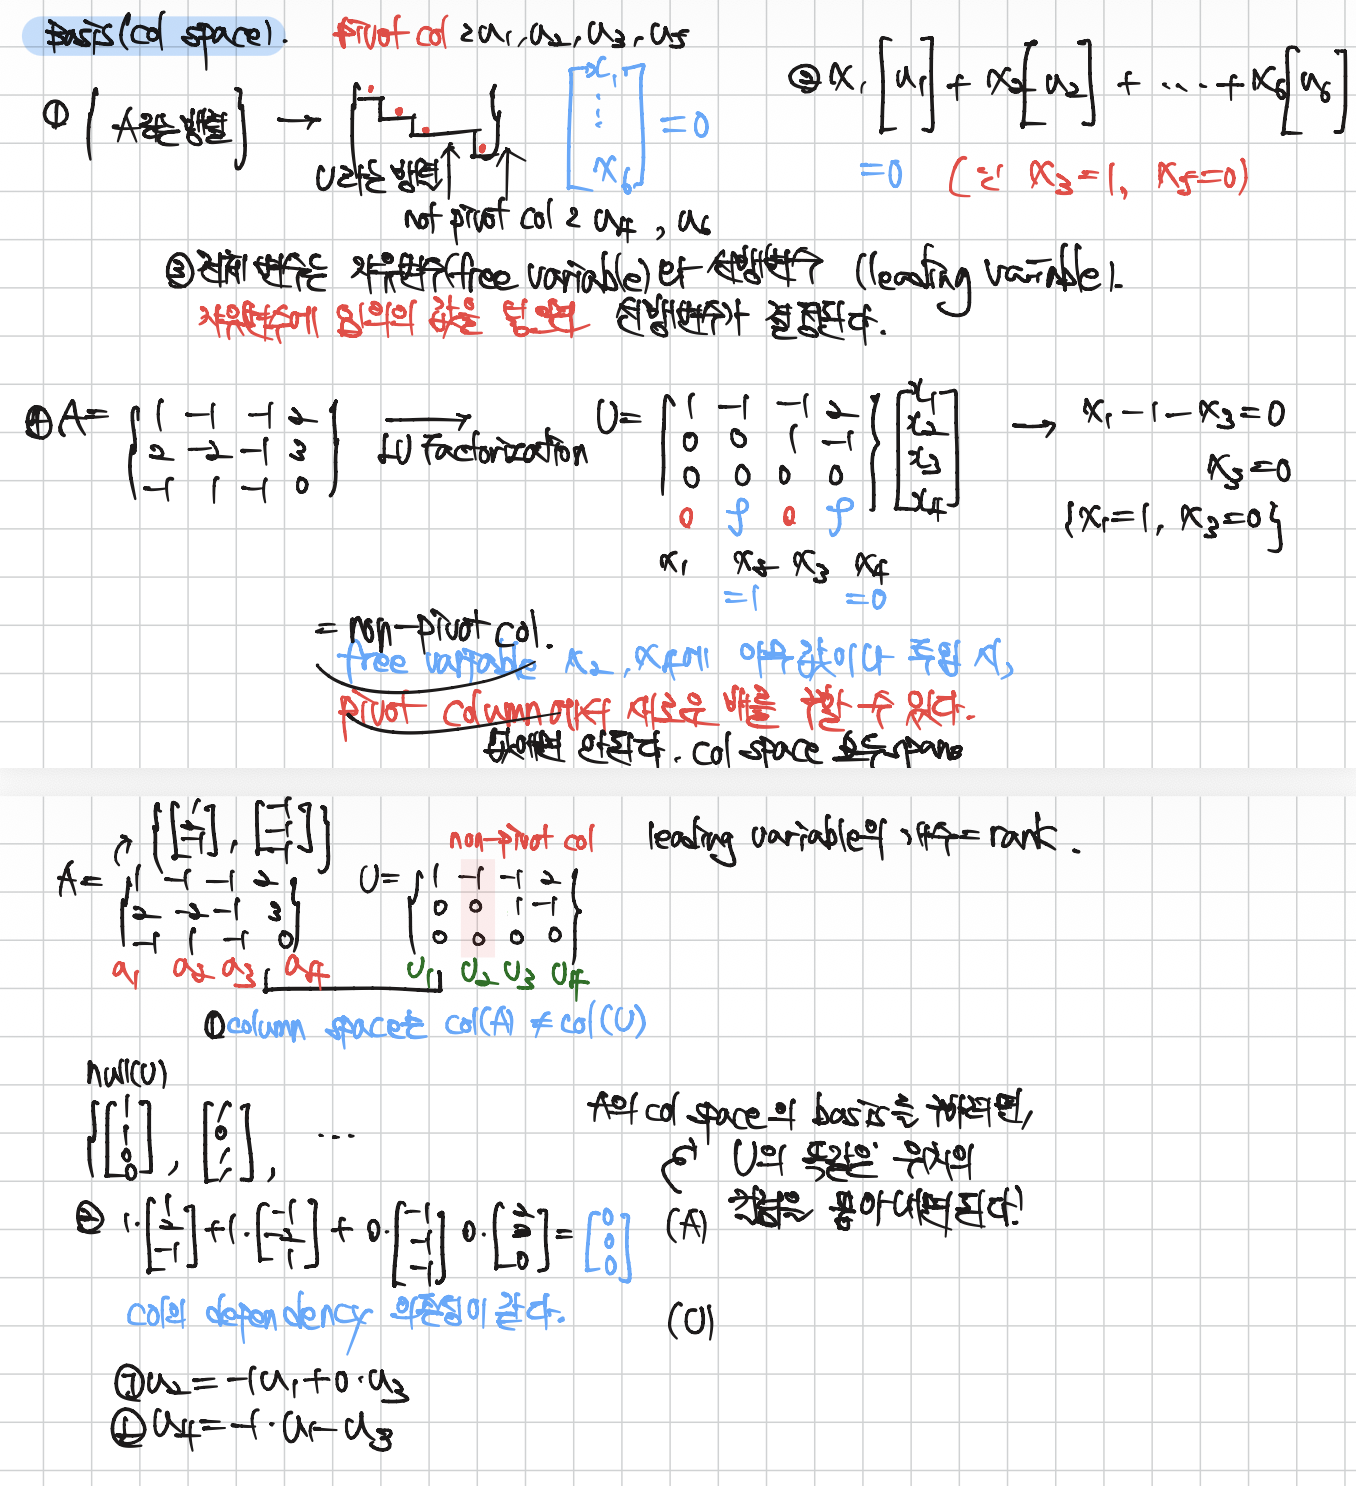

---

## 부분공간의 기저(Basis for Subspace)

부분공간의 기저를 구하는 알고리즘:
1. **행공간(row space)의 기저**: 행렬 A를 RREF로 변환한 후, 영 아닌 행벡터들이 기저
2. **열공간(column space)의 기저**: RREF의 피벗 열에 대응하는 원본 행렬 A의 열벡터들이 기저
3. **영공간(null space)의 기저**: Ax = 0의 해에서 자유변수를 매개변수로 하는 벡터들이 기저

**기저 수(Rank and Nullity)**:
- rank(A) = dim(row(A)) = dim(col(A))
- nullity(A) = dim(null(A)) = n - rank(A)
- rank(A) + nullity(A) = n